# DNA Sequence Analysis Toolkit
A basic bioinformatics workflow for analyzing DNA sequences using Python and Biopython.

## 1. Introduction
This project demonstrates basic computational analysis of DNA sequences, including sequence composition, GC content, reverse complement, transcription, translation, ORF detection, and motif searching.

In [1]:
!pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 28.4 MB/s eta 0:00:00


In [2]:
from Bio.Seq import Seq
from Bio import SeqIO
import matplotlib.pyplot as plt
from collections import Counter

In [3]:
dna = Seq("ATGGCCATTGTAATGGGCCGCTGAAAGGGTGCCCGATAG")

print(dna)
print("Sequence length:", len(dna))

ATGGCCATTGTAATGGGCCGCTGAAAGGGTGCCCGATAG
Sequence length: 39


In [4]:
composition = Counter(dna)

print(composition)

Counter({'G': 14, 'A': 9, 'T': 8, 'C': 8})


In [5]:
gc_content = ((composition["G"] + composition["C"]) / len(dna)) * 100

print("GC Content:", gc_content, "%")

GC Content: 56.41025641025641 %


In [6]:
for base in "ATGC":
    percentage = (composition[base] / len(dna)) * 100
    print(base, ":", percentage, "%")

A : 23.076923076923077 %
T : 20.51282051282051 %
G : 35.8974358974359 %
C : 20.51282051282051 %


In [7]:
reverse_complement = dna.reverse_complement()

print("Original DNA:", dna)
print("Reverse Complement:", reverse_complement)

Original DNA: ATGGCCATTGTAATGGGCCGCTGAAAGGGTGCCCGATAG
Reverse Complement: CTATCGGGCACCCTTTCAGCGGCCCATTACAATGGCCAT


In [8]:
rna = dna.transcribe()

print("DNA:", dna)
print("RNA:", rna)

DNA: ATGGCCATTGTAATGGGCCGCTGAAAGGGTGCCCGATAG
RNA: AUGGCCAUUGUAAUGGGCCGCUGAAAGGGUGCCCGAUAG


In [9]:
protein = rna.translate()

print("Protein:", protein)

Protein: MAIVMGR*KGAR*


In [10]:
def find_orfs(sequence):
    start_codon = "ATG"
    stop_codons = ["TAA", "TAG", "TGA"]

    orfs = []

    for i in range(len(sequence) - 2):
        codon = sequence[i:i+3]

        if codon == start_codon:
            for j in range(i + 3, len(sequence) - 2, 3):
                stop = sequence[j:j+3]

                if stop in stop_codons:
                    orfs.append((i, j + 3, sequence[i:j+3]))
                    break

    return orfs

In [11]:
orfs = find_orfs(dna)

In [12]:
print(orfs)

[(0, 24, Seq('ATGGCCATTGTAATGGGCCGCTGA')), (12, 24, Seq('ATGGGCCGCTGA'))]


In [13]:
for start, end, orf in orfs:
    protein = orf.translate()
    print("ORF:", start, "-", end)
    print("Protein:", protein)
    print()

ORF: 0 - 24
Protein: MAIVMGR*

ORF: 12 - 24
Protein: MGR*



In [14]:
motif = "ATG"

positions = []

for i in range(len(dna) - len(motif) + 1):
    if dna[i:i+len(motif)] == motif:
        positions.append(i)

print("Motif:", motif)
print("Positions:", positions)

Motif: ATG
Positions: [0, 12]


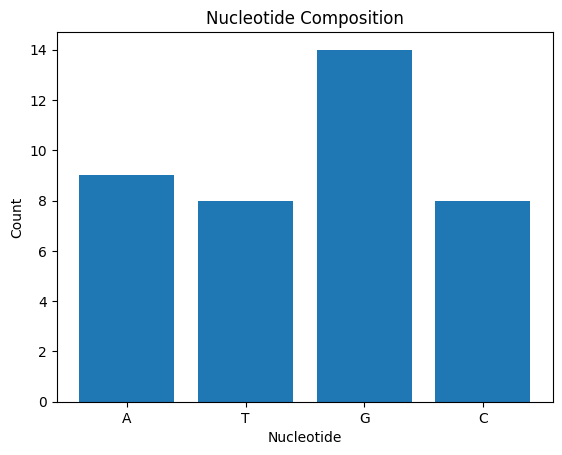

In [15]:
bases = ["A", "T", "G", "C"]
counts = [composition[base] for base in bases]

plt.bar(bases, counts)
plt.xlabel("Nucleotide")
plt.ylabel("Count")
plt.title("Nucleotide Composition")

plt.savefig("nucleotide_composition.png", dpi=300, bbox_inches="tight")
plt.show()

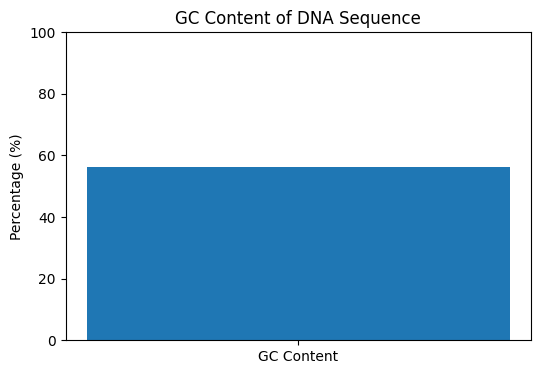

In [16]:
plt.figure(figsize=(6, 4))

plt.bar(["GC Content"], [56.41])

plt.ylim(0, 100)
plt.ylabel("Percentage (%)")
plt.title("GC Content of DNA Sequence")

plt.savefig("gc_content.png", dpi=300, bbox_inches="tight")
plt.show()

## 2. FASTA Input and Sequence Loading

In [17]:
fasta_text = """>Test_Sequence
ATGGCCATTGTAATGGGCCGCTGAAAGGGTGCCCGATAG
"""

with open("sequence.fasta", "w") as file:
    file.write(fasta_text)

In [18]:
records = list(SeqIO.parse("sequence.fasta", "fasta"))

print("Number of sequences:", len(records))
print("Sequence ID:", records[0].id)
print("Sequence length:", len(records[0].seq))

Number of sequences: 1
Sequence ID: Test_Sequence
Sequence length: 39


### Sequence Information

In [19]:
dna = records[0].seq

print("DNA sequence:", dna)

DNA sequence: ATGGCCATTGTAATGGGCCGCTGAAAGGGTGCCCGATAG


## 3. Sequence Analysis

### 3.1 Nucleotide Composition

In [20]:
composition = Counter(dna)

print("Nucleotide composition:")
print(composition)

Nucleotide composition:
Counter({'G': 14, 'A': 9, 'T': 8, 'C': 8})


### 3.2 GC Content

In [21]:
gc_content = ((composition["G"] + composition["C"]) / len(dna)) * 100

print("GC Content:", gc_content, "%")

GC Content: 56.41025641025641 %


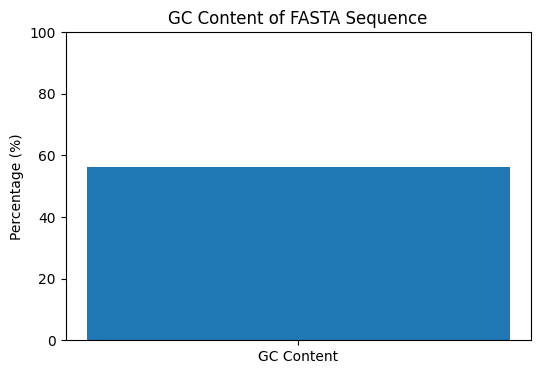

In [22]:
plt.figure(figsize=(6, 4))

plt.bar(["GC Content"], [gc_content])

plt.ylim(0, 100)
plt.ylabel("Percentage (%)")
plt.title("GC Content of FASTA Sequence")

plt.savefig("fasta_gc_content.png", dpi=300, bbox_inches="tight")
plt.show()

### 3.3 Nucleotide Percentages

In [23]:
print("Nucleotide percentages:")

for base in "ATGC":
    percentage = (composition[base] / len(dna)) * 100
    print(base, ":", round(percentage, 2), "%")

Nucleotide percentages:
A : 23.08 %
T : 20.51 %
G : 35.9 %
C : 20.51 %


### 3.4 Reverse Complement

In [24]:
reverse_complement = dna.reverse_complement()

print("Original DNA:", dna)
print("Reverse Complement:", reverse_complement)

Original DNA: ATGGCCATTGTAATGGGCCGCTGAAAGGGTGCCCGATAG
Reverse Complement: CTATCGGGCACCCTTTCAGCGGCCCATTACAATGGCCAT


### 3.5 Transcription

In [25]:
rna = dna.transcribe()

print("DNA:", dna)
print("RNA:", rna)

DNA: ATGGCCATTGTAATGGGCCGCTGAAAGGGTGCCCGATAG
RNA: AUGGCCAUUGUAAUGGGCCGCUGAAAGGGUGCCCGAUAG


### 3.6 Translation

In [26]:
protein = rna.translate()

print("Protein:", protein)

Protein: MAIVMGR*KGAR*


### 3.7 ORF Detection

In [27]:
def find_orfs(sequence):
    start_codon = "ATG"
    stop_codons = ["TAA", "TAG", "TGA"]

    orfs = []

    for i in range(len(sequence) - 2):
        codon = sequence[i:i+3]

        if codon == start_codon:
            for j in range(i + 3, len(sequence) - 2, 3):
                stop = sequence[j:j+3]

                if stop in stop_codons:
                    orfs.append((i, j + 3, sequence[i:j+3]))
                    break

    return orfs

In [28]:
orfs = find_orfs(dna)

print("ORFs found:", len(orfs))
print(orfs)

ORFs found: 2
[(0, 24, Seq('ATGGCCATTGTAATGGGCCGCTGA')), (12, 24, Seq('ATGGGCCGCTGA'))]


In [29]:
for start, end, orf in orfs:
    protein = orf.translate()

    print("ORF:", start, "-", end)
    print("Protein:", protein)
    print()

ORF: 0 - 24
Protein: MAIVMGR*

ORF: 12 - 24
Protein: MGR*



### 3.8 Motif Search

In [30]:
motif = "ATG"

positions = []

for i in range(len(dna) - len(motif) + 1):
    if dna[i:i+len(motif)] == motif:
        positions.append(i)

print("Motif:", motif)
print("Positions:", positions)

Motif: ATG
Positions: [0, 12]


### 3.9 Visualization

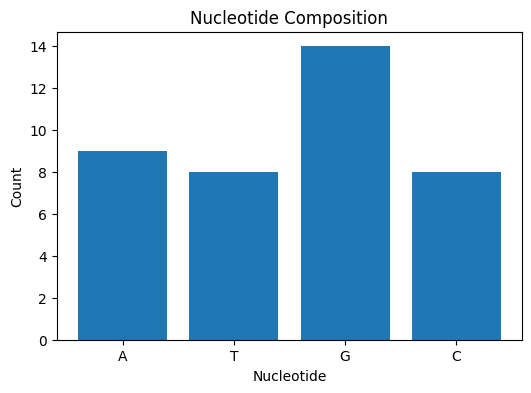

In [31]:
bases = ["A", "T", "G", "C"]
counts = [composition[base] for base in bases]

plt.figure(figsize=(6, 4))
plt.bar(bases, counts)
plt.xlabel("Nucleotide")
plt.ylabel("Count")
plt.title("Nucleotide Composition")

plt.savefig("nucleotide_composition.png", dpi=300, bbox_inches="tight")
plt.show()

## 4. Conclusion
This project demonstrated a basic computational workflow for DNA sequence analysis using Python and Biopython. The sequence was analyzed for nucleotide composition, GC content, reverse complement, transcription, translation, ORFs, and motif positions. A FASTA-based workflow was also implemented to load and analyze the sequence. These analyses demonstrate how computational tools can be used to obtain basic biological information from DNA sequences.